# **Linear Regression Model for Student Performance Factors**

## *Introduction*

> The following is a Linear Regression Algorithm designed to predict student performance factors, with reference to other listed factors such as: 
> Hours Studied, Parental Involvement, Educational Level etc. 

> *(For more information, you can refer to the dataset)* 

>  [URL for Dataset](https://www.kaggle.com/code/ahmedezzatibrahem/student-performance-factors)

## **Walkthrough**

### *Imports* 

Run the following metrics to test metrics of the model

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt                          # Used to embed the visualizations within Jupyter notebook
import seaborn as sns                                    # Make the datasets look stunning. Like a boss.
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LinearRegression        # This is the model we are using to predict the exam score. 


### *Dataset*




In [ ]:
raw_data = pd.read_csv('StudentPerformanceFactors2.csv')

> Method to read through the **dataset** (.csv file)

### *Training*

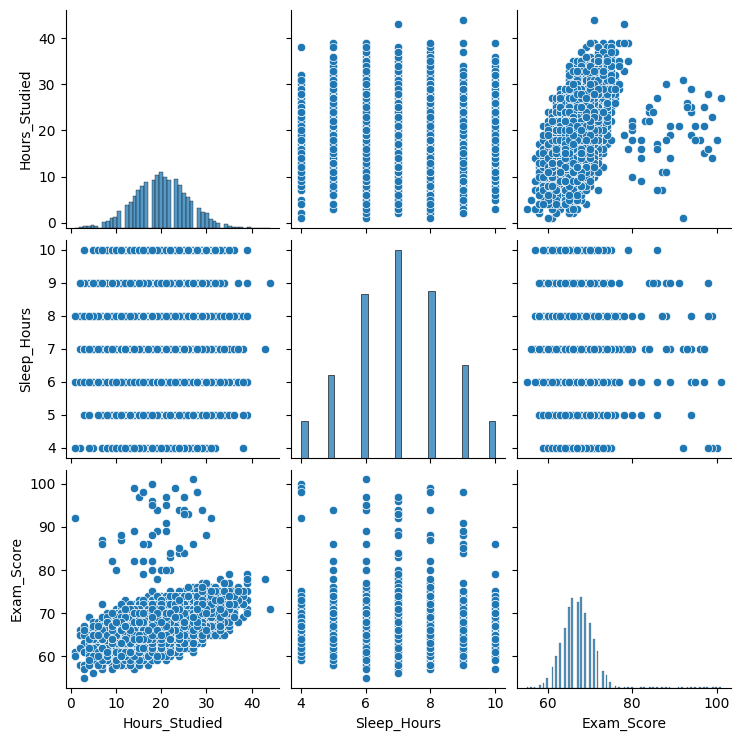

In [23]:
sns.pairplot(raw_data[['Hours_Studied', 'Sleep_Hours', 'Exam_Score']])                    # This will show the relationship between the selected variables in the dataset.

index = raw_data.columns


# Clean data/Preprocessing Layer
raw_data = raw_data.dropna()
raw_data = pd.get_dummies(raw_data, drop_first=True)

X = raw_data.drop('Exam_Score', axis=1)
y = raw_data['Exam_Score']




X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
print(model.coef_) 
# Examining the coefficients of the model.
# The large coefficients are the ones that are most important for predicting the exam score. 
# For example, the coefficient of Hours_Studied is 0.80, which means that for every hour studied, the exam score increases by 0.80.

print(model.coef_)

coef_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficients'])
print(coef_df)


[ 0.29583382  0.19868938 -0.01282938  0.04851359  0.48277682  0.20022405
 -2.01234139 -1.03853331 -2.05032244 -1.01082453  0.56672263 -1.10729809
 -0.59888074  0.9006084  -1.14852255 -0.62083425 -1.05051238 -0.60615018
  0.04895936  0.56186729  1.01488049 -0.87048418 -0.47620465  0.52157639
  0.30496393  0.84182865 -0.01080161]
[ 0.29583382  0.19868938 -0.01282938  0.04851359  0.48277682  0.20022405
 -2.01234139 -1.03853331 -2.05032244 -1.01082453  0.56672263 -1.10729809
 -0.59888074  0.9006084  -1.14852255 -0.62083425 -1.05051238 -0.60615018
  0.04895936  0.56186729  1.01488049 -0.87048418 -0.47620465  0.52157639
  0.30496393  0.84182865 -0.01080161]
                                       Coefficients
Hours_Studied                              0.295834
Attendance                                 0.198689
Sleep_Hours                               -0.012829
Previous_Scores                            0.048514
Tutoring_Sessions                          0.482777
Physical_Activity           

### *Outputs*

In [26]:

# Predictions
predictions = model.predict(X_test)

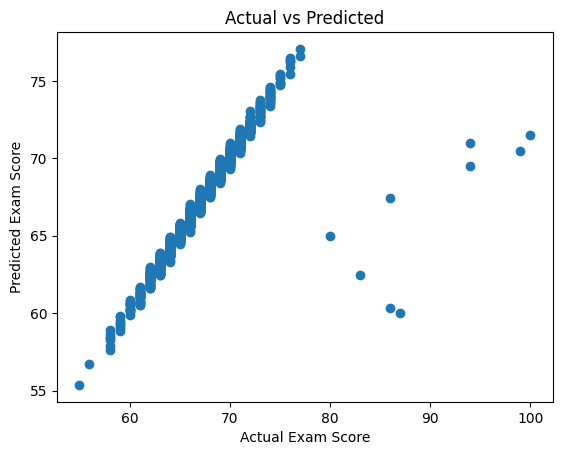

In [27]:
# Visualization
plt.scatter(y_test, predictions)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted")
plt.show()

#### **Expected Output** ####

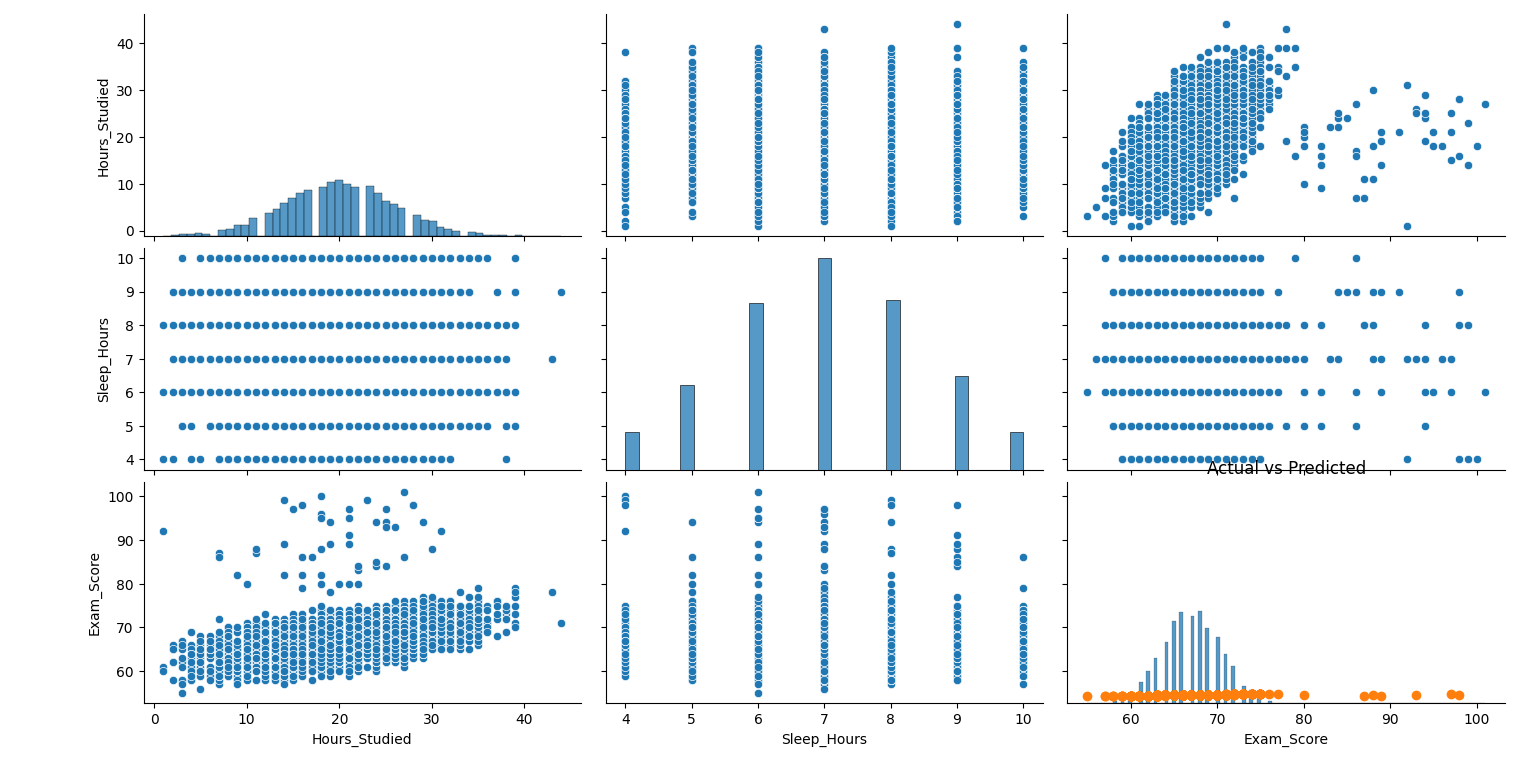

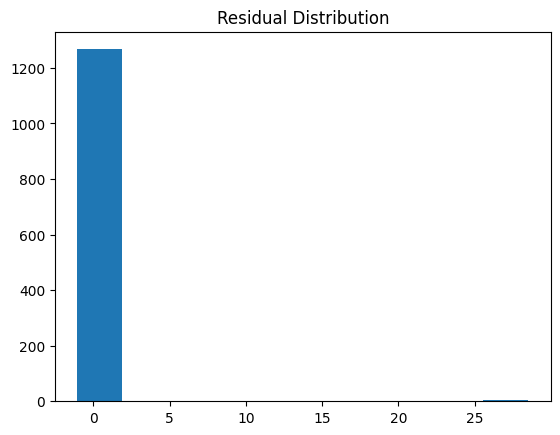

In [28]:
# Residuals
plt.hist(y_test - predictions)
plt.title("Residual Distribution")
plt.show()

#### **Expected Output** ####
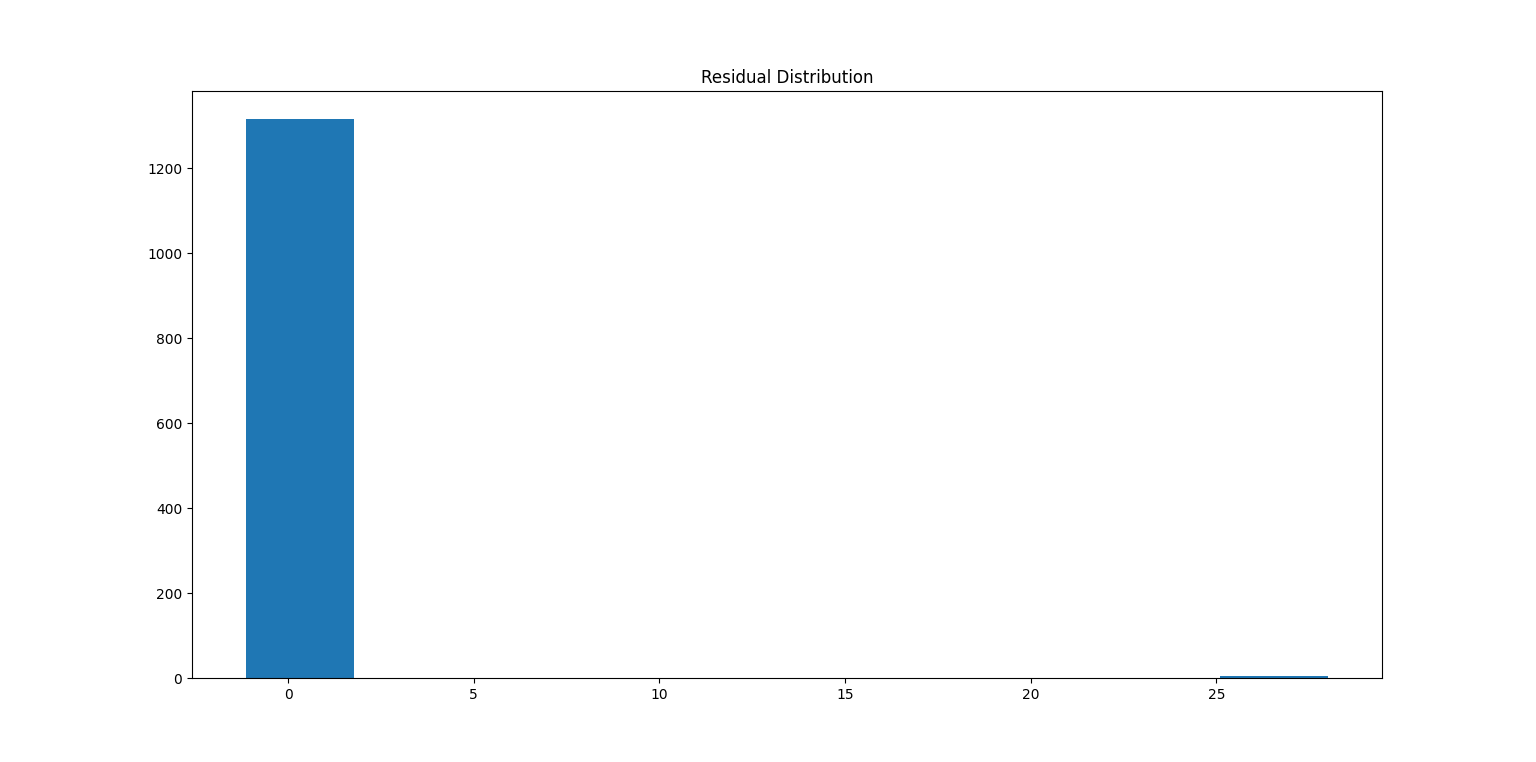

> Lack of residual distribution indicates insufficiency in model

### *Evaluation*

In [ ]:
from sklearn import metrics
import numpy as np

print("Mean Absolute Error:", metrics.mean_absolute_error(y_test, predictions))
print("Mean Squared Error:", metrics.mean_squared_error(y_test, predictions))
print("Root Mean Squared Error:", np.sqrt(metrics.mean_squared_error(y_test, predictions)))

Mean Absolute Error: 0.48728723427430676
Mean Squared Error: 4.173262062207911
Root Mean Squared Error: 2.042856348891892


#### **Expected Output** ####

Mean Absolute Error: 0.48728723427430676
Mean Squared Error: 4.173262062207911
Root Mean Squared Error: 2.042856348891892